# BTC ML Test

In [ ]:
from datetime import datetime

import research
import data

<module 'research' from '/Users/nick/Documents/Apps/quant-trading-labs/src/research.py'>

In [3]:
research.set_seed(123)

sym = 'BTCUSDT'
interval = '1h'
max_lags = 4
forecast_horizon = 1
annualized_rate = research.sharpe_to_annualized_rate(interval, 365, 24)
start_date = datetime(2025, 1, 1, 0, 0)
end_date = datetime(2026, 1, 1, 0, 0)

data.download_date_range(sym, start_date, end_date)

In [4]:
ts = research.load_ohlc_timeseries_range(sym, interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 366/366 [00:28<00:00, 13.02day/s]


datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616
…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263


In [5]:
import polars as pl

research.load_timeseries_range(sym, interval, start_date, end_date, pl.col('price').quantile(0.5).alias('price_median'))

Loading BTCUSDT: 100%|██████████| 366/366 [00:26<00:00, 13.88day/s]


datetime,price_median
datetime[μs],f64
2025-01-01 00:00:00,93856.8
2025-01-01 01:00:00,93918.3
2025-01-01 02:00:00,93744.3
2025-01-01 03:00:00,93826.0
2025-01-01 04:00:00,93663.3
…,…
2026-01-01 19:00:00,88214.4
2026-01-01 20:00:00,88282.7
2026-01-01 21:00:00,88327.8


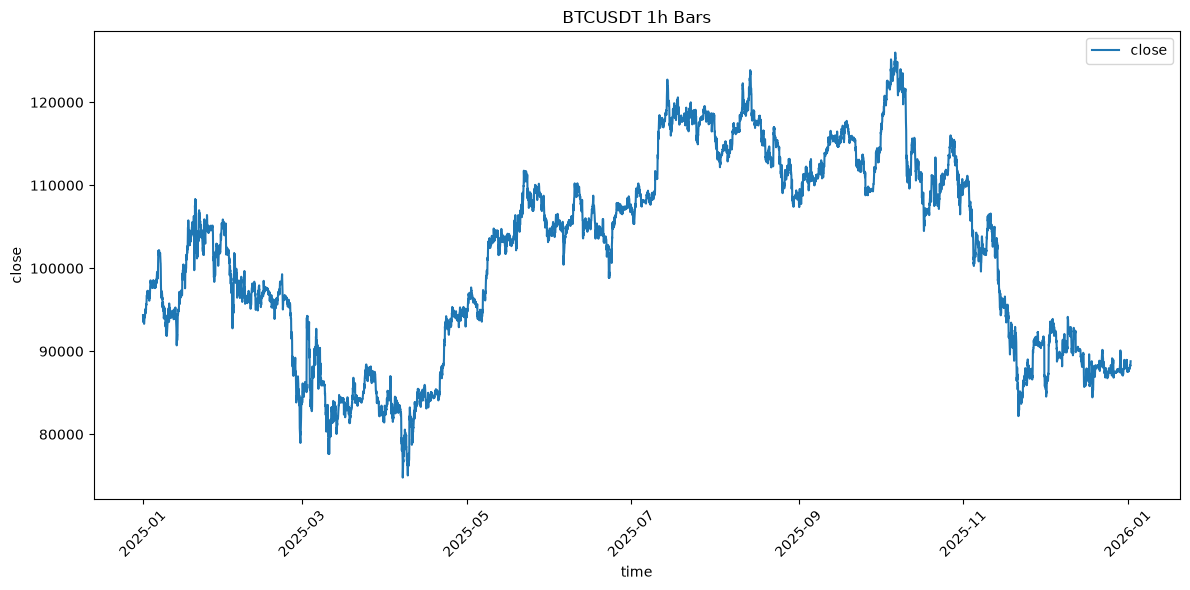

In [7]:

research.plot_timeseries(ts, sym, 'close', interval)

In [9]:
import altair

altair.data_transformers.enable('vegafusion')
research.plot_timeseries(ts, sym, 'close', interval, 'dynamic')

alt.Chart(...)

In [16]:
ts = ts.with_columns((pl.col('close') / pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,volume,log_return,close_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253,-0.008253
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077,0.005077
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708,-0.002708
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829,-0.002829
…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002147
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001522
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.001433


In [19]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon + 1).alias(f'{target}_t+{forecast_horizon + 1}'),
    lr.shift(forecast_horizon + 2).alias(f'{target}_t+{forecast_horizon + 2}'),
    lr.shift(forecast_horizon + 3).alias(f'{target}_t+{forecast_horizon + 3}'),
    lr.shift(forecast_horizon + 4).alias(f'{target}_t+{forecast_horizon + 4}')
)
ts

datetime,open,high,low,close,volume,log_return,close_log_return,close_log_return_t+1,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null,null,null,null,null,null,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253,-0.008253,null,null,null,null,null
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077,0.005077,-0.008253,null,null,null,null
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708,-0.002708,0.005077,-0.008253,null,null,null
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829,-0.002829,-0.002708,0.005077,-0.008253,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.000522
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001522,0.002147,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.001433,-0.001522,0.002147,-0.001315,0.003703,-0.000361


In [26]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,volume,log_return,close_log_return,close_log_return_t+1,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null,null,null,null,null,null,null,null,null,null,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253,-0.008253,null,null,null,null,null,null,null,null,null
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077,0.005077,-0.008253,null,null,null,null,-0.008253,null,null,null
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708,-0.002708,0.005077,-0.008253,null,null,null,0.005077,-0.008253,null,null
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829,-0.002829,-0.002708,0.005077,-0.008253,null,null,-0.002708,0.005077,-0.008253,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001522,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.001433,-0.001522,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [52]:
ts = ts.drop_nulls()
ts

datetime,open,high,low,close,volume,log_return,close_log_return,close_log_return_t+1,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 06:00:00,93760.0,93760.0,93533.3,93734.2,1970.927,-0.000275,-0.000275,0.002296,-0.002829,-0.002708,0.005077,-0.008253,0.002296,-0.002829,-0.002708,0.005077
2025-01-01 07:00:00,93734.2,93785.4,93627.7,93660.7,1157.915,-0.000784,-0.000784,-0.000275,0.002296,-0.002829,-0.002708,0.005077,-0.000275,0.002296,-0.002829,-0.002708
2025-01-01 08:00:00,93660.7,93735.2,93258.8,93398.2,3525.325,-0.002807,-0.002807,-0.000784,-0.000275,0.002296,-0.002829,-0.002708,-0.000784,-0.000275,0.002296,-0.002829
2025-01-01 09:00:00,93398.2,93462.9,92796.5,93382.1,8669.812,-0.000172,-0.000172,-0.002807,-0.000784,-0.000275,0.002296,-0.002829,-0.002807,-0.000784,-0.000275,0.002296
2025-01-01 10:00:00,93382.1,93510.0,93250.1,93307.7,2989.11,-0.000797,-0.000797,-0.000172,-0.002807,-0.000784,-0.000275,0.002296,-0.000172,-0.002807,-0.000784,-0.000275
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001522,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.001433,-0.001522,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [53]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [54]:
research.plot_distribution(ts, 'close', no_bins = 100)
# This is why we use log returns instead of raw prices.
# The distribution of log returns is more Gaussian-like, which is a common assumption in many financial models.

alt.Chart(...)

In [55]:
import torch.nn as nn

class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        # this function defines the forward pass of the model, 
        # which is how the input data flows through the model to produce an output
        return self.linear(x)
    

In [56]:
input_features = 1
linear_model = LinearModel(input_features)

# Count all parameters in the model
total_params = sum(p.numel() for p in linear_model.parameters())

# Count only parameters that will be updated during training
trainable_params = sum(
    p.numel() for p in linear_model.parameters() if p.requires_grad
)

# Print formatted model information
print(f"\n{'='*60}")
print(f"{LinearModel.__name__}")
print(f"{'='*60}")
print(f"\nArchitecture:")
print(f"  {linear_model}")
print(f"\nParameter Count:")
print(f"  Total parameters:      {total_params:,}")
print(f"  Trainable parameters:  {trainable_params:,}")

# Warn if some parameters are frozen
if total_params != trainable_params:
    frozen_params = total_params - trainable_params
    print(f"  Frozen parameters:     {frozen_params:,}")
    print(f"\n  ⚠️  Note: {frozen_params:,} parameters are frozen")

print(f"{'='*60}\n")

for name, param in linear_model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Should be y = mx + b, where m is the slope and b is the y-intercept.



LinearModel

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2

linear.weight:
[[-0.72684026]]
linear.bias:
[-0.7950419]


In [57]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

print(f"Sample: {len(ts)}")
print(f"Test Size: {int(len(ts) * test_size)}")

split_idx = int(len(ts) * (1 - test_size))
print(f"Split Index: {split_idx}")

Sample: 8778
Test Size: 2194
Split Index: 6583


In [58]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]
print(f"Training Sample: {len(ts_train)}")
print(f"Testing Sample: {len(ts_test)}")

ts_train

Training Sample: 6583
Testing Sample: 2195


datetime,open,high,low,close,volume,log_return,close_log_return,close_log_return_t+1,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 06:00:00,93760.0,93760.0,93533.3,93734.2,1970.927,-0.000275,-0.000275,0.002296,-0.002829,-0.002708,0.005077,-0.008253,0.002296,-0.002829,-0.002708,0.005077
2025-01-01 07:00:00,93734.2,93785.4,93627.7,93660.7,1157.915,-0.000784,-0.000784,-0.000275,0.002296,-0.002829,-0.002708,0.005077,-0.000275,0.002296,-0.002829,-0.002708
2025-01-01 08:00:00,93660.7,93735.2,93258.8,93398.2,3525.325,-0.002807,-0.002807,-0.000784,-0.000275,0.002296,-0.002829,-0.002708,-0.000784,-0.000275,0.002296,-0.002829
2025-01-01 09:00:00,93398.2,93462.9,92796.5,93382.1,8669.812,-0.000172,-0.000172,-0.002807,-0.000784,-0.000275,0.002296,-0.002829,-0.002807,-0.000784,-0.000275,0.002296
2025-01-01 10:00:00,93382.1,93510.0,93250.1,93307.7,2989.11,-0.000797,-0.000797,-0.000172,-0.002807,-0.000784,-0.000275,0.002296,-0.000172,-0.002807,-0.000784,-0.000275
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-02 08:00:00,118444.1,118647.7,118307.3,118635.4,2205.712,0.001614,0.001614,-0.001315,0.002282,-0.002423,-0.000676,-0.000003,-0.001315,0.002282,-0.002423,-0.000676
2025-10-02 09:00:00,118635.3,118827.7,118521.7,118813.3,2704.861,0.001498,0.001498,0.001614,-0.001315,0.002282,-0.002423,-0.000676,0.001614,-0.001315,0.002282,-0.002423
2025-10-02 10:00:00,118813.3,118885.8,118530.8,118575.3,2351.811,-0.002005,-0.002005,0.001498,0.001614,-0.001315,0.002282,-0.002423,0.001498,0.001614,-0.001315,0.002282


In [59]:
ts_test

datetime,open,high,low,close,volume,log_return,close_log_return,close_log_return_t+1,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-10-02 13:00:00,119360.0,119733.0,118868.2,119559.6,11332.135,0.00167,0.00167,0.005411,0.001186,-0.002005,0.001498,0.001614,0.005411,0.001186,-0.002005,0.001498
2025-10-02 14:00:00,119559.6,119747.2,118606.2,118768.0,11360.065,-0.006643,-0.006643,0.00167,0.005411,0.001186,-0.002005,0.001498,0.00167,0.005411,0.001186,-0.002005
2025-10-02 15:00:00,118768.1,119889.0,118458.4,119875.1,13518.21,0.009278,0.009278,-0.006643,0.00167,0.005411,0.001186,-0.002005,-0.006643,0.00167,0.005411,0.001186
2025-10-02 16:00:00,119875.1,120291.0,119564.9,119694.0,11959.603,-0.001512,-0.001512,0.009278,-0.006643,0.00167,0.005411,0.001186,0.009278,-0.006643,0.00167,0.005411
2025-10-02 17:00:00,119694.0,119916.8,119317.0,119869.1,5205.304,0.001462,0.001462,-0.001512,0.009278,-0.006643,0.00167,0.005411,-0.001512,0.009278,-0.006643,0.00167
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001522,0.002147,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.001433,-0.001522,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [60]:
import torch

x_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
x_test = torch.tensor(ts_test[features].to_numpy(), dtype=torch.float32)
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)


In [61]:
x_train

tensor([[ 0.0023],
        [-0.0003],
        [-0.0008],
        ...,
        [ 0.0015],
        [-0.0020],
        [ 0.0012]])

In [62]:
x_test.shape

torch.Size([2195, 1])

In [63]:
y_train

tensor([-0.0003, -0.0008, -0.0028,  ..., -0.0020,  0.0012,  0.0054])

In [64]:
y_train.shape

torch.Size([6583])

In [66]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

y_train.shape

torch.Size([6583, 1])

In [ ]:
import importlib
importlib.reload(research)

# make the above re-usable
x_train, x_test, y_train, y_test = research.timeseries_train_test_split(ts, features, target, test_size)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

(torch.Size([6583, 1]),
 torch.Size([2195, 1]),
 torch.Size([6583, 1]),
 torch.Size([2195, 1]))

In [ ]:
no_epochs = 5000 # we can adjust this number based on how well the model is learning. More epochs can lead to better learning, but also risk overfitting.
lr = 0.0005 # learning rate, which controls how much to change the model in response to the estimated error each time the model weights are updated.

model = LinearModel(input_features)
criterion = nn.MSELoss()  # Mean Squared Error loss
optimiser = torch.optim.Adam(model.parameters(), lr=lr)

print(f"Training model for {no_epochs} epochs with learning rate {lr}...")

for epoch in range(no_epochs):
    y_hat = model(x_train)  # Forward pass: Compute predicted y by passing x to the model
    loss = criterion(y_hat, y_train)  # Compute and print loss

    # Zero gradients, perform a backward pass, and update the weights
    optimiser.zero_grad() # clear the old gradients
    loss.backward() # compute the gradients
    optimiser.step() # update the weights

    train_loss = loss.item() # get the scalar value of the loss for logging
    if epoch % 100 == 0:
        print(f"Epoch: [{epoch}/{no_epochs}], Loss: {train_loss}")

print("Training complete.")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation for inference
    y_hat = model(x_test)  # Get predictions for the test set
    test_loss = criterion(y_hat, y_test).item()  # Calculate the test loss
    print(f"Test Loss: {test_loss} | Train Loss: {train_loss}") # pyright: ignore[reportPossiblyUnboundVariable]

Training model for 5000 epochs with learning rate 0.0005...
Epoch: [0/5000], Loss: 0.3682323396205902
Epoch: [100/5000], Loss: 0.31084591150283813
Epoch: [200/5000], Loss: 0.2603910565376282
Epoch: [300/5000], Loss: 0.21636784076690674
Epoch: [400/5000], Loss: 0.1782236248254776
Epoch: [500/5000], Loss: 0.1454257369041443
Epoch: [600/5000], Loss: 0.11746139079332352
Epoch: [700/5000], Loss: 0.09383752197027206
Epoch: [800/5000], Loss: 0.07408170402050018
Epoch: [900/5000], Loss: 0.05774294212460518
Epoch: [1000/5000], Loss: 0.04439326375722885
Epoch: [1100/5000], Loss: 0.033629339188337326
Epoch: [1200/5000], Loss: 0.02507469803094864
Epoch: [1300/5000], Loss: 0.018381671980023384
Epoch: [1400/5000], Loss: 0.013233324512839317
Epoch: [1500/5000], Loss: 0.009345118887722492
Epoch: [1600/5000], Loss: 0.006466003600507975
Epoch: [1700/5000], Loss: 0.0043787299655377865
Epoch: [1800/5000], Loss: 0.0028993606101721525
Epoch: [1900/5000], Loss: 0.0018757878569886088
Epoch: [2000/5000], Loss:

In [86]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.numpy().flatten(),
    'y': y_test.numpy().flatten()
}).with_columns(
    (pl.col('y_hat').sign() == pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
-0.000069,0.00167,false,-1.0,-0.00167,-0.00167
0.000004,-0.006643,false,1.0,-0.006643,-0.008313
0.000169,0.009278,true,1.0,0.009278,0.000965
-0.000146,-0.001512,true,-1.0,0.001512,0.002477
0.000067,0.001462,true,1.0,0.001462,0.003939
…,…,…,…,…,…
0.000063,0.002147,true,1.0,0.002147,-0.1758
-0.000005,-0.001522,true,-1.0,0.001522,-0.174277
0.000067,0.001433,true,1.0,0.001433,-0.172844


In [108]:
research.plot_line(trade_results, 'equity_curve')

alt.Chart(...)

In [88]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve') - pl.col('equity_curve').cum_max()).alias('log_drawdown')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,log_drawdown
f32,f32,bool,f32,f32,f32,f32
-0.000069,0.00167,false,-1.0,-0.00167,-0.00167,0.0
0.000004,-0.006643,false,1.0,-0.006643,-0.008313,-0.006643
0.000169,0.009278,true,1.0,0.009278,0.000965,0.0
-0.000146,-0.001512,true,-1.0,0.001512,0.002477,0.0
0.000067,0.001462,true,1.0,0.001462,0.003939,0.0
…,…,…,…,…,…,…
0.000063,0.002147,true,1.0,0.002147,-0.1758,-0.222655
-0.000005,-0.001522,true,-1.0,0.001522,-0.174277,-0.221133
0.000067,0.001433,true,1.0,0.001433,-0.172844,-0.2197


In [98]:
import numpy as np

max_drawdown_log = trade_results['log_drawdown'].min()
assert isinstance(max_drawdown_log, (int, float))
drawdown_pct = np.exp(max_drawdown_log) - 1
print(f"Max Drawdown (log): {max_drawdown_log:.4f}")
print(f"Max Drawdown (%): {drawdown_pct:.2%}")

win_rate = trade_results['is_won'].mean()
avg_win = trade_results.filter(pl.col('is_won') == True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won') == False)['trade_log_return'].mean()

# fix typing issues
assert isinstance(win_rate, (int, float))
assert isinstance(avg_win, (int, float))
assert isinstance(avg_loss, (int, float))
print(f"Win Rate: {win_rate:.2%}")

print(f"Average Win: {avg_win:.4f}")
print(f"Average Loss: {avg_loss:.4f}")

ev = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
print(f"Expected Value (EV): {ev:.4f}")

Max Drawdown (log): -0.2536
Max Drawdown (%): -22.40%
Win Rate: 50.80%
Average Win: 0.0032
Average Loss: -0.0034
Expected Value (EV): -0.0001


In [100]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return

-0.1721593737602234

In [106]:
# take it out of log space
assert isinstance(total_log_return, (int, float))
compound_return = np.exp(total_log_return) - 1
print(f"Compound Return: {compound_return:.4f}")
print(f"Profit/Loss on $1000: ${1000 * compound_return:.2f}")

Compound Return: -0.1582
Profit/Loss on $1000: $-158.16


In [109]:
equity_trough = trade_results['equity_curve'].min()
equity_peak = trade_results['equity_curve'].max()
print(f"Equity Peak: {equity_peak:.4f}")
print(f"Equity Trough: {equity_trough:.4f}")

Equity Peak: 0.0469
Equity Trough: -0.2068


In [113]:
std = trade_results['trade_log_return'].std()
print(f"Standard Deviation of Returns: {std:.4f}"
      )
assert isinstance(std, (int, float))
sharpe_ratio = ev / std * annualized_rate
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Standard Deviation of Returns: 0.0049
Sharpe Ratio: -1.4949


In [122]:
perf = research.eval_model_performance(y_test, y_hat, features, target, annualized_rate, log=True)

Features:         close_log_return_lag_1
Target:           close_log_return
No. Trades:       2195
Win Rate:         50.80%
Average Win:      0.0032
Average Loss:     -0.0034
Best Trade:       0.0340
Worst Trade:      -0.0378
Expected Value:   -0.0001
Std Dev:          0.0049
Total Log Return: -0.1722
Compound Return:  -15.82%
Max Drawdown:     -0.2536
Equity Trough:    -0.2068
Equity Peak:      0.0469
Sharpe Ratio:     -1.4949


In [ ]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(input_features)
perf = research.benchmark_model_performance(ts, features, target, model, annualized_rate, no_epochs=50, log=True)

Features:         close_log_return_lag_2
Target:           close_log_return
No. Trades:       2195
Win Rate:         50.25%
Average Win:      0.0034
Average Loss:     -0.0032
Best Trade:       0.0378
Worst Trade:      -0.0340
Expected Value:   0.0001
Std Dev:          0.0049
Total Log Return: 0.2958
Compound Return:  34.41%
Max Drawdown:     -0.1358
Equity Trough:    -0.0540
Equity Peak:      0.3731
Sharpe Ratio:     2.5687
Weights:          [-0.82085603]
Biases:           -0.26221928000450134


In [135]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:
    model = LinearModel(input_features)
    perf = research.benchmark_model_performance(ts, list(features), target, model, annualized_rate, no_epochs=200, criterion=nn.L1Loss(), log=False)
    benchmarks.append(perf)

benchmark = pl.DataFrame(benchmarks).sort('sharpe', descending=True)

benchmark

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",2195,0.502506,0.00341,-0.003174,0.037794,-0.033952,0.000135,0.004909,0.295758,0.344145,-0.135837,-0.054026,0.373127,2.568746,"""[-0.8450308]""","""-0.5732346773147583"""
"""close_log_return_lag_3""","""close_log_return""",2195,0.502506,0.00341,-0.003174,0.037794,-0.033952,0.000135,0.004909,0.295758,0.344145,-0.135837,-0.054026,0.373127,2.568746,"""[-0.13759908]""","""-0.010013864375650883"""
"""close_log_return_lag_2""","""close_log_return""",2195,0.499317,0.003244,-0.00334,0.037794,-0.033952,-0.000052,0.004911,-0.114985,-0.10862,-0.296323,-0.23645,0.059873,-0.998358,"""[-0.29533023]""","""6.160364137031138e-05"""
"""close_log_return_lag_4""","""close_log_return""",2195,0.497494,0.003174,-0.00341,0.033952,-0.037794,-0.000135,0.004909,-0.295758,-0.256033,-0.427153,-0.373127,0.054026,-2.568746,"""[-1.074859]""","""0.36828041076660156"""
